# Facility List Enrichment: Moratoria, Distance, and Community Variables

Merges the facility list with county-level regulatory variables, prior-moratorium status (own county and adjacent counties), geospatial distance variables, and local advocacy-organization density. Run against the real merged dataset.

### Load the merged facility list and county regulatory data

In [1]:
import numpy as np
import pandas as pd


dc_merge_path = "DC_List (merge) files/dc_merged_updated_with_dates.csv"

dc_merged = pd.read_csv(dc_merge_path, encoding='latin-1')  
county_data= pd.read_csv("Regulatory_County/master_county_regulatory.csv", encoding='latin-1') 

dc_merged['County'] = dc_merged['County'].str.strip()   
print(dc_merged.shape)

(1303, 161)


### Merge water-withdrawal regulatory variables

In [2]:
#Add new county variables to dc_merge by merging on County name. We will add the following variables: water_withdrawal_permit, water_withdrawal_threshold.
dc_merged = dc_merged.merge(county_data[['state','county','water_withdrawal_permit', 'water_withdrawal_threshold']], left_on=['State', 'County'], right_on=['state', 'county'], how='left').drop(columns=['county'])

print(dc_merged.shape)

(1373, 164)


### Zoning-at-time-of-approval variables

In [3]:
#Convert dc_operational_date to numeric (if it's not already)
dc_merged['dc_operational_date'] = pd.to_numeric(dc_merged['dc_operational_date'], errors='coerce')
dc_merged['zoning_byright_change_year'] = pd.to_numeric(dc_merged['zoning_byright_change_year'], errors='coerce')
dc_merged['zoning_cup_change_year'] = pd.to_numeric(dc_merged['zoning_cup_change_year'], errors='coerce')
dc_merged['zoning_ordinance_change_year'] = pd.to_numeric(dc_merged['zoning_ordinance_change_year'], errors='coerce')       


# Add new columns for at_time_by_right, at_time_cup, at_time_zoning_ordinance
# The logic is: if there was a change in the zoning variable and the change year is at least 2 years before the operational date (so during the approval process), then use the prior value; otherwise, use the current value from the merged dataset.
dc_merged['at_time_by_right']=dc_merged['zoning_dc_byright_industrial']
dc_merged['at_time_by_right'] = np.where(
    (dc_merged['dc_operational_date'].notna()) &
    (dc_merged['zoning_byright_change_year'] > (dc_merged['dc_operational_date']-2)),
    dc_merged['zoning_byright_prior'], 
    dc_merged['at_time_by_right']
)
dc_merged['at_time_cup'] = dc_merged['zoning_dc_cup_required']
dc_merged['at_time_cup'] = np.where(
    (dc_merged['dc_operational_date'].notna()) &
    (dc_merged['zoning_cup_change_year'] > (dc_merged['dc_operational_date']-2)),
    dc_merged['zoning_cup_prior'], 
    dc_merged['at_time_cup']
)
dc_merged['at_time_zoning_ordinance'] = dc_merged['zoning_dc_specific_ordinance']   
dc_merged['at_time_zoning_ordinance'] = np.where(
    (dc_merged['dc_operational_date'].notna()) &
    (dc_merged['zoning_ordinance_change_year'] > (dc_merged['dc_operational_date']-2)), 
    dc_merged['zoning_ordinance_prior'], 
    dc_merged['at_time_zoning_ordinance']
)


### Prior-moratorium exposure (own county and adjacent) + intermediate save

In [4]:
#Convert dc_operational_date to numeric (if it's not already)
dc_merged['dc_operational_date'] = pd.to_numeric(dc_merged['dc_operational_date'], errors='coerce')

# Add new column for prior moratorium status or moratorium adjacent state
#Same logic applies: if the moratorium was in place at least 2 years before the operational date, then we consider it a "prior moratorium" for that DC; if an adjacent county had a moratorium in place at least 2 years before the operational date, then we consider it "adjacent prior moratorium" for that DC.

# Load all moratorium data into dictionaries
moratoria_counties = {}
moratoria_adjacent_counties = {}

for i in range(2020, 2026):
    moratoria_counties[i] = pd.read_csv(
        f"moratoria/moratorium_counties_moratoria{i}.csv", 
        encoding='latin-1'
    )
    moratoria_adjacent_counties[i] = pd.read_csv(
        f"moratoria/moratorium_counties_touching_moratoria{i}.csv", 
        encoding='latin-1'
    )
print(moratoria_counties[2020].columns)
# Initialize columns with 0
dc_merged["prior_moratorium"] = 0
dc_merged["adjacent_prior_moratorium"] = 0


# Update based on operational year
for i in range(2020, 2026):
    year = i
    filter_by_operating_year = ((dc_merged['dc_operational_date']-1) >= year) | (dc_merged['dc_operational_date'].isna())
    
    dc_merged.loc[
        filter_by_operating_year & (dc_merged['County'].isin(moratoria_counties[i]['county'])), 
        "prior_moratorium"
    ] = 1
    
    dc_merged.loc[
        filter_by_operating_year & (dc_merged['County'].isin(moratoria_adjacent_counties[i]['county'])), 
        "adjacent_prior_moratorium"
    ] = 1
    
print(dc_merged['prior_moratorium'].value_counts())
print(dc_merged['adjacent_prior_moratorium'].value_counts())


output_path = "DC_List (merge) files/dc_merged_updated_with_moratoria_and_distance_vars.csv"
dc_merged.to_csv(output_path, index=False, encoding='latin-1')

Index(['state', 'county', 'city', 'is_statewide', 'is_county_level',
       'governing_body', 'ordinance_name', 'ordinance_type', 'date_enacted',
       'date_expires', 'status', 'description', 'source_url',
       'direct_opposition_to_dc', 'dc_name', 'dc_address', 'moratorium_days'],
      dtype='str')
prior_moratorium
0    1150
1     223
Name: count, dtype: int64
adjacent_prior_moratorium
0    1099
1     274
Name: count, dtype: int64


### Merge tribal-land and historic-site distance variables

In [5]:
#Add new column for distance to nearest tribal land (in miles) and distance to nearest historical site
tribal_distance_path = "Distance_to_variables/dc_with_tribal_land_distance.csv"
historical_distance_path = "Distance_to_variables/dc_with_closest_nrhp_distance.csv" 

dc_tribal_distance = pd.read_csv(tribal_distance_path, encoding='latin-1')
dc_historical_distance = pd.read_csv(historical_distance_path, encoding='latin-1')      
dc_merged = dc_merged.merge(dc_tribal_distance[['Facility_number', 'dist_tribal_land_miles']], on='Facility_number', how='left')
dc_merged = dc_merged.merge(dc_historical_distance[['Facility_number', 'dist_nearest_nrhp_miles']], on='Facility_number', how='left')   
print(dc_merged.shape)

(1373, 168)


### Historic landmarks per county (with state-abbreviation crosswalk)

In [6]:
#Add column for number of historical landmarks per county
historical_landmarks_path = "Distance_to_variables/nrhp_by_county.csv"
historical_landmarks = pd.read_csv(historical_landmarks_path, encoding='latin-1') 

#Dictionary of state name to abbreviation for merging
state_dict = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'District of Columbia': 'DC'
}

#Turn state names into abbreviations in historical_landmarks for merging    
historical_landmarks['State_Abbr'] = historical_landmarks['State'].str.title().map(state_dict) 
print(historical_landmarks['State_Abbr'])

dc_merged = dc_merged.merge(historical_landmarks[['State_Abbr', 'County', 'Historical_Sites']], left_on=['State', 'County'], right_on=['State_Abbr', 'County'], how='left').drop(columns=['State_Abbr'])    
print("after hist: ", dc_merged.shape)

0       AL
1       AL
2       AL
3       AL
4       AL
        ..
3178    WY
3179    WY
3180    WY
3181    WY
3182    WY
Name: State_Abbr, Length: 3183, dtype: str
after hist:  (1373, 169)


### Nonprofit/advocacy-org density, final save

In [7]:
#Add column from presence of community organizations
org_path= "Community Variables/org_density_by_county_vars.csv"
org_density= pd.read_csv(org_path, encoding='latin-1')
org_density['CENSUS_COUNTY_NAME'] = org_density['CENSUS_COUNTY_NAME'].str.removesuffix('County').str.strip()
dc_merged = dc_merged.merge(org_density[['CENSUS_STATE_ABBR', 'CENSUS_COUNTY_NAME', 'Org_Count', 'Avg_Org_Assets_log']], left_on=['State', 'County'], right_on=['CENSUS_STATE_ABBR', 'CENSUS_COUNTY_NAME'], how='left').drop(columns=[ 'CENSUS_STATE_ABBR', 'CENSUS_COUNTY_NAME'])  

print(dc_merged.shape)

#Save the updated dataframe to a new CSV file
output_path = "DC_List (merge) files/dc_merged_updated_with_moratoria_and_distance_vars.csv"
dc_merged.to_csv(output_path, index=False, encoding='latin-1')

(1373, 171)


## Visualization

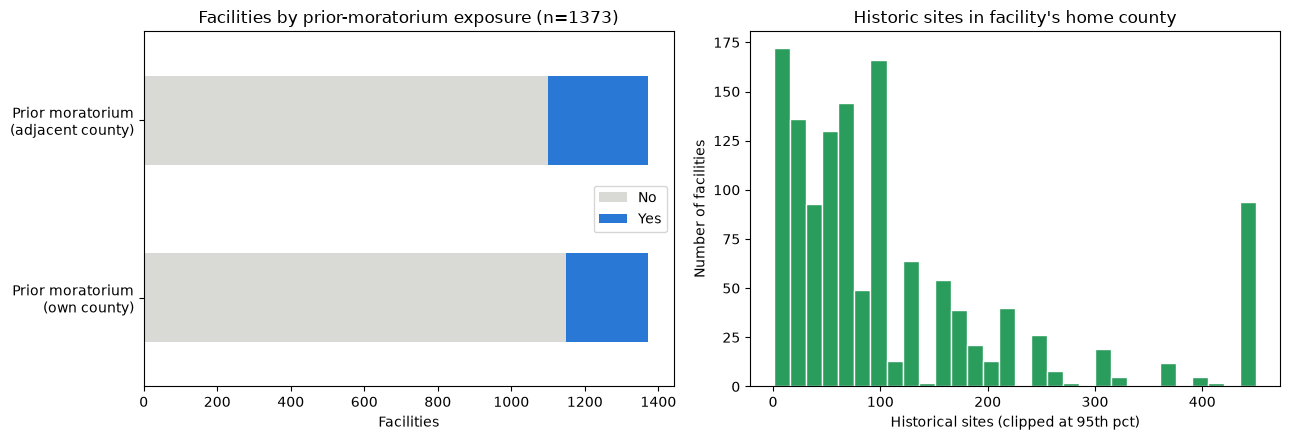

In [8]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



import pandas as pd
df = pd.read_csv("DC_List (merge) files/dc_merged_updated_with_moratoria_and_distance_vars.csv", encoding='latin-1', low_memory=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mor = pd.DataFrame({
    "Prior moratorium\n(own county)": df["prior_moratorium"].value_counts().reindex([0,1], fill_value=0),
    "Prior moratorium\n(adjacent county)": df["adjacent_prior_moratorium"].value_counts().reindex([0,1], fill_value=0),
}).T
mor.columns = ["No", "Yes"]
mor.plot(kind="barh", stacked=True, ax=axes[0], color=["#d9d9d6", "#2a78d6"])
axes[0].set_title(f"Facilities by prior-moratorium exposure (n={len(df)})")
axes[0].set_xlabel("Facilities")
axes[0].legend(title="")

if "Historical_Sites" in df.columns:
    hs = df["Historical_Sites"].dropna()
    axes[1].hist(hs.clip(upper=hs.quantile(0.95)), bins=30, color="#2a9d5c", edgecolor="white")
    axes[1].set_title("Historic sites in facility's home county")
    axes[1].set_xlabel("Historical sites (clipped at 95th pct)")
    axes[1].set_ylabel("Number of facilities")

plt.tight_layout()
plt.show()
